# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.segment_targeting_estimators import *
from core.dgp import *
from core.segment_targeting_experiments import *
from core.visualization import *

# Model Tests

In [16]:
# parameters
train_size = 100
test_size = 10
n_segments = 2
te_diff = 0.1
segment_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = SegmentTargetingDGP(
    n_segments=n_segments, te_diff=te_diff, segment_func=segment_func, 
    noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size, seed=1)

# train estimators 
# plugin estimator
plugin_estmr = SegmentTargetingPlugin(dgp.segment_func, n_segments).fit(train_x, train_t, train_y)

# value correction estimator
vc_estmr = SegmentTargetingValueCorrection(dgp.segment_func, n_segments=n_segments).fit(train_x, train_t, train_y, n_bootstraps=500)
# value correction estimator with m-out-of-n bootstrap 
mnbvc_estmr = SegmentTargetingMNBValueCorrection(dgp.segment_func, n_segments=n_segments).fit(
    train_x, train_t, train_y, n_bootstraps=500, 
    # q=0.9, max_j=20, m_method='Bickle-Sakov', 
    power=0.95, m_method='power', 
)  
# value correction estimator with numerical bootstrap
nbvc_estmr = SegmentTargetingNBValueCorrection(dgp.segment_func, n_segments=n_segments).fit(
    train_x, train_t, train_y, n_bootstraps=500, power=-0.45
)

# # error correction estimator
ec_estmr = SegmentTargetingErrorCorrection(dgp.segment_func, n_segments=n_segments).fit(train_x, train_t, train_y, n_bootstraps=500)
# error correction estimator with m-out-of-n bootstrap 
mnbec_estmr = SegmentTargetingMNBErrorCorrection(dgp.segment_func, n_segments=n_segments).fit(
    train_x, train_t, train_y, n_bootstraps=500, 
    # q=0.95, max_j=20, m_method='Bickle-Sakov', 
    power=0.95, m_method='power', 
) 
# # error correction estimator with numerical bootstrap
nbec_estmr = SegmentTargetingNBErrorCorrection(dgp.segment_func, n_segments=n_segments).fit(
    train_x, train_t, train_y, n_bootstraps=500, power=-0.45
)

In [17]:
test_x = dgp.sample_individuals(test_size, seed=1)

# evalute test set 
budget = 1

# plugin estimator and its performance
plugin_decision, plugin_targ_est = plugin_estmr.optimize(test_customers=test_x, budget=budget)
true_plugin_targ_val = segment_targeting_obj_func(
    test_customers=test_x, targ_decision=plugin_decision, params=dgp.segment_te_arr, 
    segment_func=dgp.segment_func
)

# value correction estimators
vc_targ_est = vc_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)
mnbvc_targ_est = mnbvc_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)
nbvc_targ_est = nbvc_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)
# error correction estimators
ec_targ_est = ec_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)
mnbec_targ_est = mnbec_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)
nbec_targ_est = nbec_estmr.estimate(test_x, budget=budget, plugin_estmr=plugin_estmr)

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Value Correction targeting estimate: {vc_targ_est:.4f}")
print(f"Value Correction with m-out-of-n Bootstrap targeting estimate: {mnbvc_targ_est:.4f}")
print(f"Value Correction with numerical bootstrap targeting estimate: {nbvc_targ_est:.4f}")
print(f"Error Correction targeting estimate: {ec_targ_est:.4f}")
print(f"Error Correction with m-out-of-n Bootstrap targeting estimate: {mnbec_targ_est:.4f}")
print(f"Error Correction with numerical bootstrap targeting estimate: {nbec_targ_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of value correction estimate: {vc_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of value correction with M-out-of-n bootstrap estimate: {mnbvc_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of value correction with numerical bootstrap estimate: {nbvc_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of error correction estimate: {ec_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of error correction with m-out-of-n bootstrap estimate: {mnbec_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of error correction with numerical bootstrap estimate: {nbec_targ_est - true_plugin_targ_val:.4f}")

Plugin targeting estimate: 0.9172
Value Correction targeting estimate: 0.8437
Value Correction with m-out-of-n Bootstrap targeting estimate: 0.7996
Value Correction with numerical bootstrap targeting estimate: 0.8099
Error Correction targeting estimate: 0.8576
Error Correction with m-out-of-n Bootstrap targeting estimate: 0.8107
Error Correction with numerical bootstrap targeting estimate: 0.8057

Actual value of plugin targeting: 1.1000
Winner's Curse of plugin estimate: -0.1828
Winner's Curse of value correction estimate: -0.2563
Winner's Curse of value correction with M-out-of-n bootstrap estimate: -0.3004
Winner's Curse of value correction with numerical bootstrap estimate: -0.2901
Winner's Curse of error correction estimate: -0.2424
Winner's Curse of error correction with m-out-of-n bootstrap estimate: -0.2893
Winner's Curse of error correction with numerical bootstrap estimate: -0.2943


# Winner's Curse

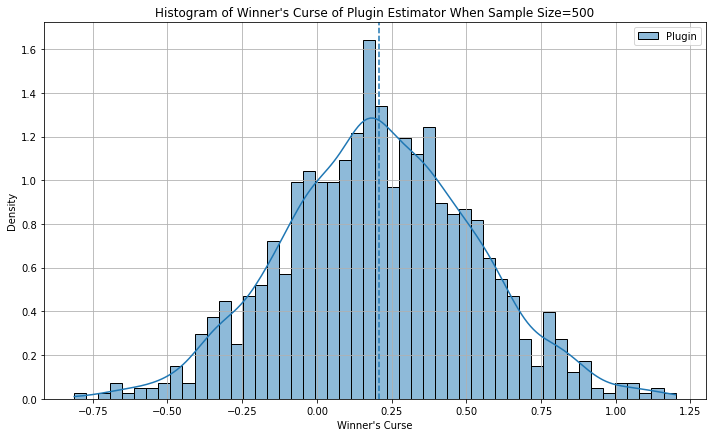

In [18]:
assert 'case2_sample_size_test.csv' in os.listdir('results'), "Please run the sample size test first"

result_df = pd.read_csv('results/case2_sample_size_test.csv')

sample_size = 500 

result_df = result_df[result_df['sample_size'] == sample_size][[col for col in result_df.columns if 'wc' in col]]

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# histogram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc'], bins=50, stat='density', ax=ax, color='C0', label='Plugin', kde=True)
ax.axvline(result_df['plugin_wc'].mean(), color='C0', linestyle='--')

ax.set_xlabel("Winner's Curse")
ax.set_ylabel("Density")
ax.set_title(f"Histogram of Winner's Curse of Plugin Estimator When Sample Size={sample_size}")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

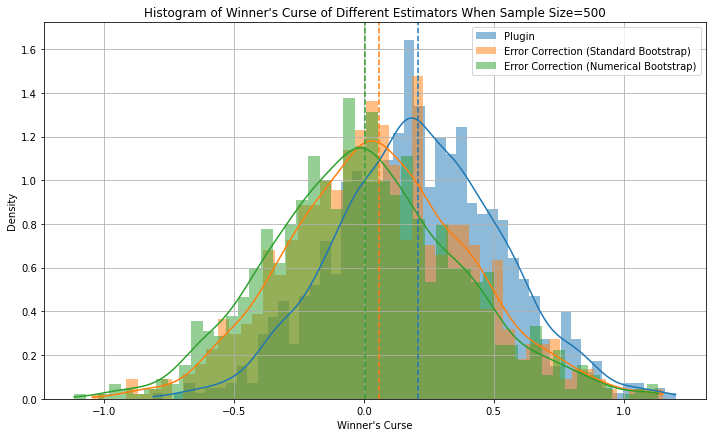

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# histogram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc'], bins=50, stat='density', ax=ax, color='C0', label='Plugin', kde=True, edgecolor=None)
ax.axvline(result_df['plugin_wc'].mean(), color='C0', linestyle='--')

# histogram of error correction (standard bootstrap) estimator's winner's curse
sns.histplot(result_df['error_correction_wc'], bins=50, stat='density', ax=ax, color='C1', label='Error Correction (Standard Bootstrap)', kde=True, edgecolor=None)
ax.axvline(result_df['error_correction_wc'].mean(), color='C1', linestyle='--')

# histogram of error correction (numerical bootstrap) estimator's winner's curse
sns.histplot(result_df['nb_error_correction_wc'], bins=50, stat='density', ax=ax, color='C2', label='Error Correction (Numerical Bootstrap)', kde=True, edgecolor=None)
ax.axvline(result_df['nb_error_correction_wc'].mean(), color='C2', linestyle='--')

ax.set_xlabel("Winner's Curse")
ax.set_ylabel("Density")
ax.set_title(f"Histogram of Winner's Curse of Different Estimators When Sample Size={sample_size}")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

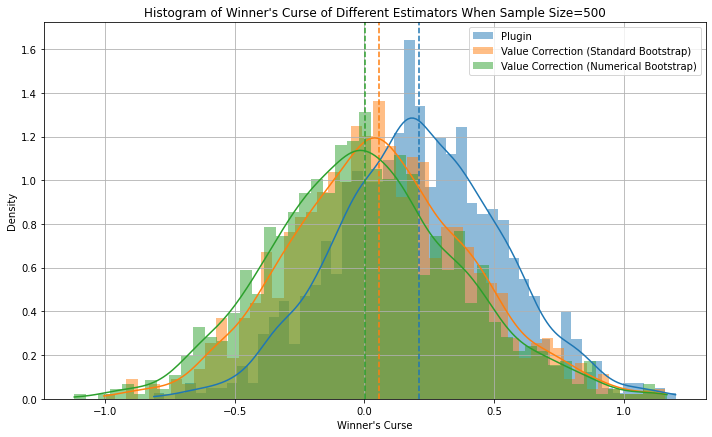

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# histogram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc'], bins=50, stat='density', ax=ax, color='C0', label='Plugin', kde=True, edgecolor=None)
ax.axvline(result_df['plugin_wc'].mean(), color='C0', linestyle='--')

# histogram of error correction (standard bootstrap) estimator's winner's curse
sns.histplot(result_df['value_correction_wc'], bins=50, stat='density', ax=ax, color='C1', label='Value Correction (Standard Bootstrap)', kde=True, edgecolor=None)
ax.axvline(result_df['value_correction_wc'].mean(), color='C1', linestyle='--')

# histogram of error correction (numerical bootstrap) estimator's winner's curse
sns.histplot(result_df['nb_value_correction_wc'], bins=50, stat='density', ax=ax, color='C2', label='Value Correction (Numerical Bootstrap)', kde=True, edgecolor=None)
ax.axvline(result_df['nb_value_correction_wc'].mean(), color='C2', linestyle='--')

ax.set_xlabel("Winner's Curse")
ax.set_ylabel("Density")
ax.set_title(f"Histogram of Winner's Curse of Different Estimators When Sample Size={sample_size}")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Sample Size

In [21]:
# parameters
dgp_params = {
    'n_segments': 2,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'segment_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': np.nan,  # size of training set
    'noise_std': 3.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': SegmentTargetingPlugin,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'error_correction': {
        'estimator': SegmentTargetingErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # error correction estimator
    'mnb_error_correction': {
        'estimator': SegmentTargetingMNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # error correction estimator with m-out-of-n bootstrap
    'nb_error_correction': {
        'estimator': SegmentTargetingNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # error correction estimator with numerical bootstrap
    'value_correction': {
        'estimator': SegmentTargetingValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # value correction estimator
    'mnb_value_correction': {
        'estimator': SegmentTargetingMNBValueCorrection, 
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # value correction estimator with m-out-of-n bootstrap
    'nb_value_correction': {
        'estimator': SegmentTargetingNBValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # value correction estimator with numerical bootstrap
}

In [23]:
result_df = sample_size_test(
    sample_sizes=[100, 200, 300, 400, 500, 750, 1000, 1500, 2000], 
    dgp_params=dgp_params, 
    targeting_params=targeting_params, 
    estimators_dict=estimators_dict, 
    num_train_samples=1000, 
    num_test_customers_per_train_sample=2, 
    save_dir='test.csv', 
    verbose=True
)

100%|██████████| 1000/1000 [16:45<00:00,  1.01s/it]


Sample size = 100; Time taken: 0:16:45.122782


100%|██████████| 1000/1000 [20:16<00:00,  1.22s/it]


Sample size = 200; Time taken: 0:20:16.084373


100%|██████████| 1000/1000 [22:01<00:00,  1.32s/it]


...

Sample size = 1000; Time taken: 0:49:29.698677


100%|██████████| 1000/1000 [43:21<00:00,  2.60s/it] 


Sample size = 1500; Time taken: 0:43:21.476482


100%|██████████| 1000/1000 [37:05<00:00,  2.23s/it]


Sample size = 2000; Time taken: 0:37:05.278736


In [6]:
result_df = pd.read_csv('results/case2_sample_size_test.csv')

sample_size_groupby = result_df[
    [col for col in result_df.columns if 'wc' in col] + ['train_sample_id', 'test_customer_id', 'sample_size']
].groupby('sample_size')

mean_df = sample_size_groupby[[col for col in result_df.columns if 'wc' in col]].mean()
se_df = sample_size_groupby[[col for col in result_df.columns if 'wc' in col]].std().apply(lambda x: x / np.sqrt(x.index))

estimators_list = [col[:-3] for col in mean_df.columns]

mean_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
sample_size,,,,,,,
100,0.481246,0.141773,0.073243,0.052907,0.141221,0.073938,0.053810
200,0.318200,0.078405,0.025102,0.006231,0.077468,0.024664,0.007187
300,0.280686,0.085493,0.040541,0.021669,0.085322,0.038722,0.022098
400,0.217754,0.051390,0.009191,-0.006338,0.051180,0.009145,-0.006804
500,0.208985,0.058379,0.019209,0.003833,0.058207,0.019288,0.003377
750,0.164967,0.044002,0.010474,-0.003149,0.043952,0.010509,-0.003303
1000,0.145488,0.041087,0.010137,-0.002371,0.040939,0.010178,-0.001628
1500,0.114605,0.029652,0.003249,-0.007417,0.030080,0.003042,-0.007794
2000,0.100764,0.027971,0.003895,-0.005664,0.027897,0.004350,-0.005956


In [7]:
se_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
sample_size,,,,,,,
100,0.072932,0.081014,0.081303,0.083623,0.080941,0.081531,0.083305
200,0.035260,0.039120,0.039295,0.040529,0.039146,0.039323,0.040496
300,0.023116,0.025661,0.025772,0.026621,0.025602,0.025780,0.026671
400,0.017900,0.019796,0.019840,0.020561,0.019806,0.019865,0.020623
500,0.014307,0.015718,0.015767,0.016316,0.015730,0.015754,0.016322
750,0.009524,0.010593,0.010640,0.011073,0.010620,0.010628,0.011061
1000,0.007174,0.007914,0.007957,0.008280,0.007932,0.007955,0.008267
1500,0.004773,0.005268,0.005284,0.005523,0.005276,0.005281,0.005503
2000,0.003592,0.003986,0.004008,0.004208,0.003992,0.004006,0.004195


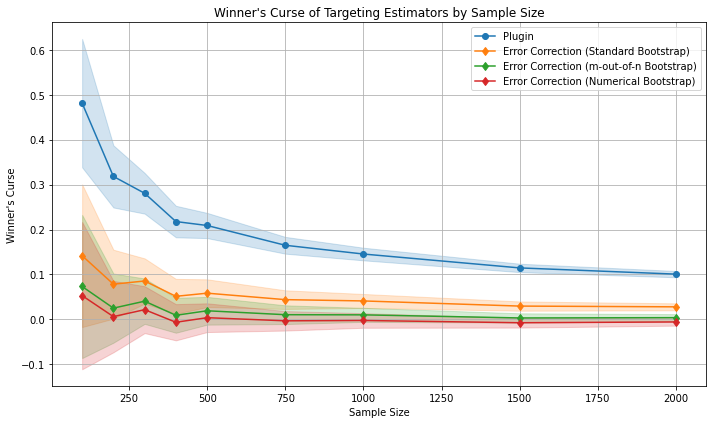

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plugin estimaotr
ax.plot(mean_df.index, mean_df['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.fill_between(
    mean_df.index, 
    mean_df['plugin_wc'] - 1.96 * se_df['plugin_wc'], 
    mean_df['plugin_wc'] + 1.96 * se_df['plugin_wc'], 
    color='C0', alpha=0.2
)

# # value correction with vanilla bootstrap
# ax.plot(mean_df.index, mean_df['value_correction_wc'], 's-', label='Value Correction (Standard Bootstrap)', color='C1')
# ax.fill_between(
#     mean_df.index, 
#     mean_df['value_correction_wc'] - 1.96 * se_df['value_correction_wc'], 
#     mean_df['value_correction_wc'] + 1.96 * se_df['value_correction_wc'], 
#     color='C1', alpha=0.2
# )

# # value correction with m-out-of-n bootstrap
# ax.plot(mean_df.index, mean_df['mnb_value_correction_wc'], 's-', label='Value Correction (m-out-of-n Bootstrap)', color='C2')
# ax.fill_between(
#     mean_df.index, 
#     mean_df['mnb_value_correction_wc'] - 1.96 * se_df['mnb_value_correction_wc'], 
#     mean_df['mnb_value_correction_wc'] + 1.96 * se_df['mnb_value_correction_wc'], 
#     color='C2', alpha=0.2
# )

# # value correction with numerical bootstrap
# ax.plot(mean_df.index, mean_df['nb_value_correction_wc'], 's-', label='Value Correction (Numerical Bootstrap)', color='C3')
# ax.fill_between(
#     mean_df.index, 
#     mean_df['nb_value_correction_wc'] - 1.96 * se_df['nb_value_correction_wc'], 
#     mean_df['nb_value_correction_wc'] + 1.96 * se_df['nb_value_correction_wc'], 
#     color='C3', alpha=0.2
# )

# error correction with vanilla bootstrap
ax.plot(mean_df.index, mean_df['error_correction_wc'], 'd-', label='Error Correction (Standard Bootstrap)', color='C1')
ax.fill_between(
    mean_df.index, 
    mean_df['error_correction_wc'] - 1.96 * se_df['error_correction_wc'], 
    mean_df['error_correction_wc'] + 1.96 * se_df['error_correction_wc'], 
    color='C1', alpha=0.2
)

# error correction with m-out-of-n bootstrap
ax.plot(mean_df.index, mean_df['mnb_error_correction_wc'], 'd-', label='Error Correction (m-out-of-n Bootstrap)', color='C2')
ax.fill_between(
    mean_df.index, 
    mean_df['mnb_error_correction_wc'] - 1.96 * se_df['mnb_error_correction_wc'], 
    mean_df['mnb_error_correction_wc'] + 1.96 * se_df['mnb_error_correction_wc'], 
    color='C2', alpha=0.2
)

# error correction with numerical bootstrap
ax.plot(mean_df.index, mean_df['nb_error_correction_wc'], 'd-', label='Error Correction (Numerical Bootstrap)', color='C3')
ax.fill_between(
    mean_df.index, 
    mean_df['nb_error_correction_wc'] - 1.96 * se_df['nb_error_correction_wc'], 
    mean_df['nb_error_correction_wc'] + 1.96 * se_df['nb_error_correction_wc'], 
    color='C3', alpha=0.2
)


ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Targeting Estimators by Sample Size')
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

## Segment Separation

In [6]:
# parameters
dgp_params = {
    'n_segments': 2,  # number of groups
    'te_diff': np.nan,  # treatment effect difference
    'segment_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 500,  # size of training set
    'noise_std': 3.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': SegmentTargetingPlugin,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'error_correction': {
        'estimator': SegmentTargetingErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # error correction estimator
    'mnb_error_correction': {
        'estimator': SegmentTargetingMNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # error correction estimator with m-out-of-n bootstrap
    'nb_error_correction': {
        'estimator': SegmentTargetingNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # error correction estimator with numerical bootstrap
    'value_correction': {
        'estimator': SegmentTargetingValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # value correction estimator
    'mnb_value_correction': {
        'estimator': SegmentTargetingMNBValueCorrection, 
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # value correction estimator with m-out-of-n bootstrap
    'nb_value_correction': {
        'estimator': SegmentTargetingNBValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # value correction estimator with numerical bootstrap
}

In [7]:
te_diff_result_df = segment_separation_test(
    te_diffs=[0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1], 
    dgp_params=dgp_params, 
    targeting_params=targeting_params, 
    estimators_dict=estimators_dict, 
    num_train_samples=1000, 
    num_test_customers_per_train_sample=2, 
    save_dir='results/case2_segment_separation_test.csv', 
    verbose=True
)

100%|██████████| 1000/1000 [22:24<00:00,  1.34s/it]


Treatment effect difference = 0.1; Time taken: 0:22:24.380961


100%|██████████| 1000/1000 [22:31<00:00,  1.35s/it]


Treatment effect difference = 0.2; Time taken: 0:22:31.624815


100%|██████████| 1000/1000 [22:18<00:00,  1.34s/it]


...

Treatment effect difference = 0.5; Time taken: 0:22:07.193281


100%|██████████| 1000/1000 [22:09<00:00,  1.33s/it]


Treatment effect difference = 0.75; Time taken: 0:22:09.509723


100%|██████████| 1000/1000 [22:51<00:00,  1.37s/it]


Treatment effect difference = 1; Time taken: 0:22:51.560836


In [22]:
assert 'case2_segment_separation_test.csv' in os.listdir('results'), "Please run the segment separation test first"

result_df = pd.read_csv('results/case2_segment_separation_test.csv')

te_diff_groupby = result_df[
    [col for col in result_df.columns if 'wc' in col] + ['train_sample_id', 'test_customer_id', 'te_diff']
].groupby('te_diff')

mean_df = te_diff_groupby[[col for col in result_df.columns if 'wc' in col]].mean()
se_df = te_diff_groupby[[col for col in result_df.columns if 'wc' in col]].std().apply(lambda x: x / np.sqrt(dgp_params['train_size']))

mean_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
te_diff,,,,,,,
0.10,0.208985,0.058379,0.019209,0.003833,0.058207,0.019288,0.003377
0.20,0.198829,0.051595,0.012721,-0.001906,0.051390,0.012896,-0.002111
0.30,0.179239,0.037985,-0.000543,-0.013752,0.037602,-0.000383,-0.013816
0.40,0.159672,0.026251,-0.011383,-0.022472,0.026095,-0.011433,-0.022541
0.50,0.133145,0.009373,-0.027449,-0.035843,0.009161,-0.027462,-0.035877
0.75,0.073562,-0.021452,-0.054804,-0.055924,-0.021451,-0.054411,-0.055942
1.00,0.031293,-0.033939,-0.062404,-0.057481,-0.033783,-0.062059,-0.057548


In [23]:
se_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
te_diff,,,,,,,
0.10,0.014307,0.015718,0.015767,0.016316,0.015730,0.015754,0.016322
0.20,0.014665,0.016047,0.016114,0.016656,0.016064,0.016109,0.016659
0.30,0.015179,0.016565,0.016669,0.017180,0.016581,0.016645,0.017197
0.40,0.015446,0.016843,0.016984,0.017464,0.016853,0.016948,0.017490
0.50,0.015857,0.017297,0.017488,0.017955,0.017318,0.017449,0.017973
0.75,0.016678,0.018217,0.018555,0.018910,0.018255,0.018507,0.018939
1.00,0.017063,0.018593,0.019037,0.019264,0.018607,0.018977,0.019293


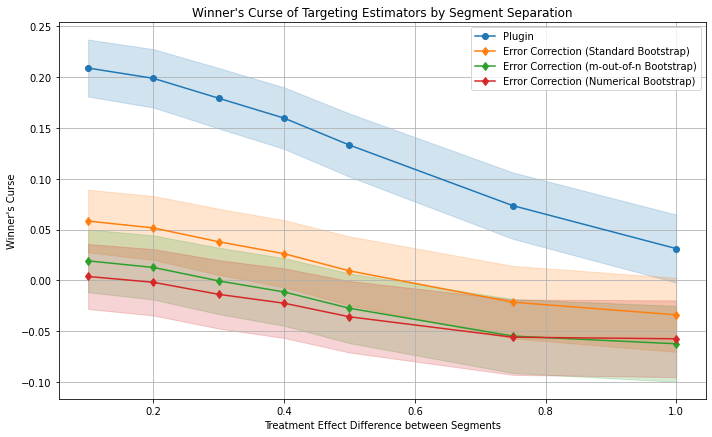

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimaotr
ax.plot(mean_df.index, mean_df['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.fill_between(
    mean_df.index, 
    mean_df['plugin_wc'] - 1.96 * se_df['plugin_wc'], 
    mean_df['plugin_wc'] + 1.96 * se_df['plugin_wc'], 
    color='C0', alpha=0.2
)

# # value correction with vanilla bootstrap
# ax.plot(mean_df.index, mean_df['value_correction_wc'], 's-', label='Value Correction (Standard Bootstrap)', color='C1')
# ax.fill_between(
#     mean_df.index,
#     mean_df['value_correction_wc'] - 1.96 * se_df['value_correction_wc'],
#     mean_df['value_correction_wc'] + 1.96 * se_df['value_correction_wc'],
#     color='C1', alpha=0.2
# )

# # value correction with m-out-of-n bootstrap
# ax.plot(mean_df.index, mean_df['mnb_value_correction_wc'], 's-', label='Value Correction (m-out-of-n Bootstrap)', color='C2')
# ax.fill_between(
#     mean_df.index,
#     mean_df['mnb_value_correction_wc'] - 1.96 * se_df['mnb_value_correction_wc'],
#     mean_df['mnb_value_correction_wc'] + 1.96 * se_df['mnb_value_correction_wc'],
#     color='C2', alpha=0.2
# )

# # value correction with numerical bootstrap
# ax.plot(mean_df.index, mean_df['nb_value_correction_wc'], 's-', label='Value Correction (Numerical Bootstrap)', color='C3')
# ax.fill_between(
#     mean_df.index,
#     mean_df['nb_value_correction_wc'] - 1.96 * se_df['nb_value_correction_wc'],
#     mean_df['nb_value_correction_wc'] + 1.96 * se_df['nb_value_correction_wc'],
#     color='C3', alpha=0.2
# )

# error correction with vanilla bootstrap
ax.plot(mean_df.index, mean_df['error_correction_wc'], 'd-', label='Error Correction (Standard Bootstrap)', color='C1')
ax.fill_between(
    mean_df.index,
    mean_df['error_correction_wc'] - 1.96 * se_df['error_correction_wc'],
    mean_df['error_correction_wc'] + 1.96 * se_df['error_correction_wc'],
    color='C1', alpha=0.2
)

# error correction with m-out-of-n bootstrap
ax.plot(mean_df.index, mean_df['mnb_error_correction_wc'], 'd-', label='Error Correction (m-out-of-n Bootstrap)', color='C2')
ax.fill_between(
    mean_df.index,
    mean_df['mnb_error_correction_wc'] - 1.96 * se_df['mnb_error_correction_wc'],
    mean_df['mnb_error_correction_wc'] + 1.96 * se_df['mnb_error_correction_wc'],
    color='C2', alpha=0.2
)

# error correction with numerical bootstrap
ax.plot(mean_df.index, mean_df['nb_error_correction_wc'], 'd-', label='Error Correction (Numerical Bootstrap)', color='C3')
ax.fill_between(
    mean_df.index,
    mean_df['nb_error_correction_wc'] - 1.96 * se_df['nb_error_correction_wc'],
    mean_df['nb_error_correction_wc'] + 1.96 * se_df['nb_error_correction_wc'],
    color='C3', alpha=0.2
)

ax.set_xlabel('Treatment Effect Difference between Segments')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Targeting Estimators by Segment Separation')
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

In [32]:
# parameters
dgp_params = {
    'n_segments': 2,  # number of groups
    'te_diff': np.nan,  # treatment effect difference
    'segment_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 500,  # size of training set
    'noise_std': 3.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': SegmentTargetingPlugin,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'error_correction': {
        'estimator': SegmentTargetingErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # error correction estimator
    'mnb_error_correction': {
        'estimator': SegmentTargetingMNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.99, 
        }, 
        'targeting_params': {}, 
    },  # error correction estimator with m-out-of-n bootstrap
    'nb_error_correction': {
        'estimator': SegmentTargetingNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.49}, 
        'targeting_params': {}, 
    },  # error correction estimator with numerical bootstrap
}

result_df = segment_separation_test(
    te_diffs=[1, 1.5, 2], 
    dgp_params=dgp_params, 
    targeting_params=targeting_params, 
    estimators_dict=estimators_dict, 
    num_train_samples=1000, 
    num_test_customers_per_train_sample=2, 
    save_dir=None, 
    verbose=True
)

100%|██████████| 1000/1000 [11:45<00:00,  1.42it/s]


Treatment effect difference = 1; Time taken: 0:11:45.727027


100%|██████████| 1000/1000 [11:47<00:00,  1.41it/s]


Treatment effect difference = 1.5; Time taken: 0:11:47.282129


100%|██████████| 1000/1000 [11:59<00:00,  1.39it/s]

Treatment effect difference = 2; Time taken: 0:11:59.531463


In [33]:
te_diff_groupby = result_df[
    [col for col in result_df.columns if 'wc' in col] + ['train_sample_id', 'test_customer_id', 'te_diff']
].groupby('te_diff')

mean_df = te_diff_groupby[[col for col in result_df.columns if 'wc' in col]].mean()
se_df = te_diff_groupby[[col for col in result_df.columns if 'wc' in col]].std().apply(lambda x: x / np.sqrt(dgp_params['train_size']))

mean_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc
te_diff,,,,
1.0,0.031293,-0.033939,-0.039005,-0.038006
1.5,-0.001728,-0.024235,-0.026427,-0.025507
2.0,-0.008490,-0.014039,-0.014376,-0.014153


In [34]:
se_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc
te_diff,,,,
1.0,0.017063,0.018593,0.018705,0.018742
1.5,0.017269,0.018166,0.018285,0.018257
2.0,0.017337,0.017655,0.017730,0.017693


## Noise Level

In [8]:
# parameters
dgp_params = {
    'n_segments': 2,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'segment_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 500,  # size of training set
    'noise_std': np.nan,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': SegmentTargetingPlugin,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'error_correction': {
        'estimator': SegmentTargetingErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # error correction estimator
    'mnb_error_correction': {
        'estimator': SegmentTargetingMNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # error correction estimator with m-out-of-n bootstrap
    'nb_error_correction': {
        'estimator': SegmentTargetingNBErrorCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # error correction estimator with numerical bootstrap
    'value_correction': {
        'estimator': SegmentTargetingValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000}, 
        'targeting_params': {}, 
    },  # value correction estimator
    'mnb_value_correction': {
        'estimator': SegmentTargetingMNBValueCorrection, 
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {
            'n_bootstraps': 1000, 
            # 'm_method': 'Bickle-Sakov', 'q': 0.99, 'max_j': 20, 
            'm_method': 'power', 'power': 0.95, 
        }, 
        'targeting_params': {}, 
    },  # value correction estimator with m-out-of-n bootstrap
    'nb_value_correction': {
        'estimator': SegmentTargetingNBValueCorrection,
        'init_params': {'segment_func': dgp_params['segment_func'], 'n_segments': dgp_params['n_segments']}, 
        'train_params': {'n_bootstraps': 1000, 'power': - 0.45}, 
        'targeting_params': {}, 
    },  # value correction estimator with numerical bootstrap
}

In [9]:
noise_std_result_df = noise_level_test(
    noise_stds=[0.5, 1, 2, 3, 4, 5, 7.5, 10], 
    dgp_params=dgp_params, 
    targeting_params=targeting_params, 
    estimators_dict=estimators_dict, 
    num_train_samples=1000, 
    num_test_customers_per_train_sample=2, 
    save_dir='results/case2_noise_level_test.csv', 
    verbose=True
)

100%|██████████| 1000/1000 [22:56<00:00,  1.38s/it]


Noise STD = 0.5; Time taken: 0:22:56.175954


 16%|█▌        | 155/1000 [03:37<18:51,  1.34s/it]/Users/iamsikun/miniforge3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 1000/1000 [44:44<00:00,  2.68s/it]   


Noise STD = 1; Time taken: 0:44:44.470836


100%|██████████| 1000/1000 [30:03<00:00,  1.80s/it]


...

Noise STD = 5; Time taken: 0:30:04.840103


100%|██████████| 1000/1000 [29:43<00:00,  1.78s/it]


Noise STD = 7.5; Time taken: 0:29:43.703002


100%|██████████| 1000/1000 [43:26<00:00,  2.61s/it]   


Noise STD = 10; Time taken: 0:43:26.821287


In [18]:
assert 'case2_noise_level_test.csv' in os.listdir('results'), "Please run the noise level test first"

result_df = pd.read_csv('results/case2_noise_level_test.csv')

noise_std_groupby = result_df[
    [col for col in result_df.columns if 'wc' in col] + ['train_sample_id', 'test_customer_id', 'noise_std']
].groupby('noise_std')

mean_df = noise_std_groupby[[col for col in result_df.columns if 'wc' in col]].mean()
se_df = noise_std_groupby[[col for col in result_df.columns if 'wc' in col]].std().apply(lambda x: x / np.sqrt(dgp_params['train_size']))

mean_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
noise_std,,,,,,,
0.5,0.017598,-0.001196,-0.007131,-0.008057,-0.001222,-0.007132,-0.008084
1.0,0.059746,0.012662,-0.000181,-0.004584,0.012534,-0.000128,-0.004605
2.0,0.135962,0.036462,0.010415,0.000423,0.036308,0.010505,0.000138
3.0,0.208985,0.058379,0.019209,0.003833,0.058207,0.019288,0.003377
4.0,0.280821,0.079502,0.027195,0.006491,0.079251,0.027321,0.005843
5.0,0.352615,0.100749,0.035239,0.009390,0.100420,0.035401,0.008488
7.5,0.531337,0.153151,0.054861,0.016148,0.152573,0.055142,0.014616
10.0,0.709517,0.205178,0.073933,0.022669,0.204435,0.074372,0.020426


In [19]:
se_df

,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc
noise_std,,,,,,,
0.5,0.002725,0.002976,0.003018,0.003091,0.002981,0.003010,0.003093
1.0,0.005060,0.005522,0.005556,0.005727,0.005527,0.005548,0.005732
2.0,0.009652,0.010585,0.010622,0.010990,0.010595,0.010615,0.010996
3.0,0.014307,0.015718,0.015767,0.016316,0.015730,0.015754,0.016322
4.0,0.019026,0.020912,0.020976,0.021712,0.020927,0.020957,0.021708
5.0,0.023730,0.026089,0.026168,0.027092,0.026110,0.026144,0.027083
7.5,0.035530,0.039066,0.039190,0.040571,0.039096,0.039153,0.040557
10.0,0.047346,0.052061,0.052220,0.054069,0.052097,0.052174,0.054054


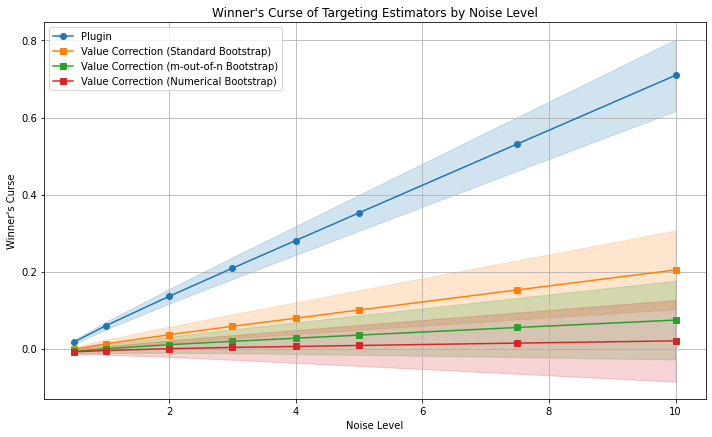

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimaotr
ax.plot(mean_df.index, mean_df['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.fill_between(
    mean_df.index, 
    mean_df['plugin_wc'] - 1.96 * se_df['plugin_wc'], 
    mean_df['plugin_wc'] + 1.96 * se_df['plugin_wc'], 
    color='C0', alpha=0.2
)

# value correction with vanilla bootstrap
ax.plot(mean_df.index, mean_df['value_correction_wc'], 's-', label='Value Correction (Standard Bootstrap)', color='C1')
ax.fill_between(
    mean_df.index,
    mean_df['value_correction_wc'] - 1.96 * se_df['value_correction_wc'],
    mean_df['value_correction_wc'] + 1.96 * se_df['value_correction_wc'],
    color='C1', alpha=0.2
)

# value correction with m-out-of-n bootstrap
ax.plot(mean_df.index, mean_df['mnb_value_correction_wc'], 's-', label='Value Correction (m-out-of-n Bootstrap)', color='C2')
ax.fill_between(
    mean_df.index,
    mean_df['mnb_value_correction_wc'] - 1.96 * se_df['mnb_value_correction_wc'],
    mean_df['mnb_value_correction_wc'] + 1.96 * se_df['mnb_value_correction_wc'],
    color='C2', alpha=0.2
)

# value correction with numerical bootstrap
ax.plot(mean_df.index, mean_df['nb_value_correction_wc'], 's-', label='Value Correction (Numerical Bootstrap)', color='C3')
ax.fill_between(
    mean_df.index,
    mean_df['nb_value_correction_wc'] - 1.96 * se_df['nb_value_correction_wc'],
    mean_df['nb_value_correction_wc'] + 1.96 * se_df['nb_value_correction_wc'],
    color='C3', alpha=0.2
)

# # error correction with vanilla bootstrap
# ax.plot(mean_df.index, mean_df['error_correction_wc'], 'd-', label='Error Correction (Standard Bootstrap)', color='C1')
# ax.fill_between(
#     mean_df.index,
#     mean_df['error_correction_wc'] - 1.96 * se_df['error_correction_wc'],
#     mean_df['error_correction_wc'] + 1.96 * se_df['error_correction_wc'],
#     color='C1', alpha=0.2
# )

# # error correction with m-out-of-n bootstrap
# ax.plot(mean_df.index, mean_df['mnb_error_correction_wc'], 'd-', label='Error Correction (m-out-of-n Bootstrap)', color='C2')
# ax.fill_between(
#     mean_df.index,
#     mean_df['mnb_error_correction_wc'] - 1.96 * se_df['mnb_error_correction_wc'],
#     mean_df['mnb_error_correction_wc'] + 1.96 * se_df['mnb_error_correction_wc'],
#     color='C2', alpha=0.2
# )

# # error correction with numerical bootstrap
# ax.plot(mean_df.index, mean_df['nb_error_correction_wc'], 'd-', label='Error Correction (Numerical Bootstrap)', color='C3')
# ax.fill_between(
#     mean_df.index,
#     mean_df['nb_error_correction_wc'] - 1.96 * se_df['nb_error_correction_wc'],
#     mean_df['nb_error_correction_wc'] + 1.96 * se_df['nb_error_correction_wc'],
#     color='C3', alpha=0.2
# )

ax.set_xlabel('Noise Level')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Targeting Estimators by Noise Level')
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

## Multiple Segments

In [ ]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
# parameters
dgp_params = {
    'num_groups': 4,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': group_func,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # adjusted bootstrap correction estimator, 
}

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000], 
    num_bootstraps=[500],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid2.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 5000, Time taken: 169.08 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 338.05 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 518.35 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 686.76 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 175.74 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 361.12 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 541.05 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 717.27 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 186.74 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 2289.31 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 1538.88 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 775.34 seconds
Sample size: 1500, Num bootstrap: 5000, Time taken: 197.85 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 399.24 seconds
Sample size: 1500, Num bootstrap: 15000, Time taken: 607.1

# Sketch